# 1. Data Cleaning and Preprocessing 

In [2]:
#pip install xgboost

In [3]:
# Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from functools import reduce
from calculation import *

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

from xgboost import XGBRegressor


In [ ]:
# Path to climate CSV files
file_paths = glob.glob("data/climate/climate*.csv")

# Read and append all CSVs into a single DataFrame
climate_df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

In [117]:
# Check data types of columns
#print(climate_df.dtypes)

In [ ]:
# Select relevant columns from climate_df
climate_df = climate_df[['Date/Time', 'Year', 'Month', 'Max Temp (°C)',
                         'Min Temp (°C)', 'Heat Deg Days (°C)', 'Cool Deg Days (°C)', 'Total Precip (mm)']]

In [119]:
# Check the first few rows
#climate_df.head()

In [121]:
#print(climate_df.dtypes)  # Check data types of columns

In [ ]:
# Column renaming dictionary for clarity
column_rename = {
    "Date/Time": "Date",
    "Max Temp (°C)": "Max_Temp",
    "Min Temp (°C)": "Min_Temp",
    "Heat Deg Days (°C)": "Heat_Degree_Days",
    "Cool Deg Days (°C)": "Cool_Degree_Days",
    "Total Precip (mm)": "Total_Precipitation"
}

# Apply renaming
climate_df.rename(columns=column_rename, inplace=True)

In [123]:
# Display updated column names
#climate_df.columns

In [125]:
# Convert 'Date' column to datetime format and handle errors (invalid dates will become NaT)
climate_df["Date"] = pd.to_datetime(climate_df["Date"], errors='coerce')

# Check for any invalid or missing date entries
#climate_df["Date"].isna().sum()  # Shows how many NaT values are present in the 'Date' column

In [127]:
# Display the tail of the dataframe
#climate_df.tail()

## Particles data set

In [11]:
# Load pollutant datasets
dfPM25 = pd.read_csv("data/particles/PM25.csv")
dfSO2 = pd.read_csv("data/particles/SO2.csv")
dfNO2 = pd.read_csv("data/particles/NO2.csv")
dfNOx = pd.read_csv("data/particles/NOx.csv")
dfNO = pd.read_csv("data/particles/NO.csv")
dfO3 = pd.read_csv("data/particles/O3.csv")

In [12]:
# Dictionary to associate DataFrames with their particles names (from filenames)
dfparticles = {
    "PM2.5": dfPM25,
    "SO2": dfSO2,
    "NO2": dfNO2,
    "NOx": dfNOx,
    "NO": dfNO,
    "O3": dfO3
}

In [ ]:
# Create an empty dictionary to store processed DataFrames for each pollutant
processed_particles = {}

for particle_name, particles_df in dfparticles.items():
    # Convert Date column to datetime format with specified format
    particles_df["Date"] = pd.to_datetime(particles_df["Date"], format="%d/%m/%Y", errors="coerce")
                                
    # Identify hourly columns (H01 to H24) specific to each DataFrame
    hourly_columns = [col for col in particles_df.columns if col.startswith("H")]

    # Replace exaggerated values (9999 and -999) with NaN
    particles_df[hourly_columns] = particles_df[hourly_columns].replace({9999: None, -999: None})

    # Compute daily average while ignoring NaN values
    particles_df[particle_name] = particles_df[hourly_columns].mean(axis=1, skipna=True)

    # Drop hourly columns, Station ID, and Pollutant columns
    columns_to_drop = hourly_columns + ["Station ID", "Pollutant"]
    particles_df.drop(columns=[col for col in columns_to_drop if col in particles_df.columns], inplace=True, errors="ignore")

    # Add a unique ID for each row
    particles_df["ID"] = particles_df.index + 1  # Creates an ID starting from 1 for each row

    # Rearrange columns for clarity
    particles_df = particles_df[["ID", "Date", particle_name]]  # Ensures ID, Date, and pollutant column are in order

    # Store the processed DataFrame for each pollutant
    processed_particles[particle_name] = particles_df

In [129]:
# Example: Display processed data for NOx
#processed_particles["NOx"].head()

In [ ]:
# Ensure all DataFrames are structured for merging
processed_dataframes = [
    df[["ID", "Date", particle_name]]  # Select ID, Date, and pollutant-specific column
    for particle_name, df in processed_particles.items()  # Use processed_particles for merged data
    if "ID" in df.columns and "Date" in df.columns
]

# Initialize the merged DataFrame using the first DataFrame
merged_particles_df = processed_dataframes[0]

# Perform iterative merging using both ID and Date
for next_df in processed_dataframes[1:]:
    merged_particles_df = pd.merge(
        merged_particles_df,
        next_df,
        on=["ID", "Date"],  # Merge using both ID and Date
        how="outer"  # Use outer join to keep all rows
    )

In [131]:
# View the merged result
#merged_particles_df.head()

In [ ]:
# Convert pollutants columns to float
particles_columns = ["PM2.5", "SO2", "NO2", "NOx", "NO", "O3"]

# Loop through each column and convert to float
for col in particles_columns:
    merged_particles_df[col] = pd.to_numeric(merged_particles_df[col], errors="coerce")

# Round all numerical columns to 2 decimal places
merged_particles_df = merged_particles_df.round(2)

In [16]:
# Calculate AQI for Each Polluant using functions defined in calculation.py
merged_particles_df["PM2.5_AQI"] = merged_particles_df["PM2.5"].apply(calculate_pm25_aqi)
merged_particles_df["NO2_AQI"] = merged_particles_df["NO2"].apply(calculate_no2_aqi) 
merged_particles_df["SO2_AQI"] = merged_particles_df["SO2"].apply(calculate_so2_aqi)
merged_particles_df["O3_AQI"] = merged_particles_df["O3"].apply(calculate_o3_aqi) 

In [17]:
# Find Maximum AQI and Dominant Pollutant
aqi_columns = ["PM2.5_AQI", "NO2_AQI", "SO2_AQI", "O3_AQI"]
merged_particles_df["AQI"] = merged_particles_df[aqi_columns].max(axis=1)
merged_particles_df["Dominant_Pollutant"] = merged_particles_df[aqi_columns].idxmax(axis=1, skipna=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_52688\2769815515.py:4: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  merged_particles_df["Dominant_Pollutant"] = merged_particles_df[aqi_columns].idxmax(axis=1, skipna=True)


In [18]:
# Count Contributions of Each Pollutant
aqi_counts = merged_particles_df["Dominant_Pollutant"].value_counts()

# Display AQI counts for each pollutant
print(aqi_counts)

Dominant_Pollutant
PM2.5_AQI    1165
O3_AQI        532
SO2_AQI       126
Name: count, dtype: int64


In [ ]:
# Drop individual AQI columns
merged_particles_df.drop(columns=["PM2.5_AQI", "SO2_AQI", "NO2_AQI", "O3_AQI"], inplace=True)

# Reorder columns: Move AQI right after Date
column_order = ["ID", "Date", "AQI", "PM2.5", "SO2", "NO2", "NOx", "NO", "O3", "Dominant_Pollutant"]
merged_particles_df = merged_particles_df[column_order]

In [133]:
# Display the final cleaned and processed DataFrame
#merged_particles_df.head()

# 2. Data Integration and Transformation

In [21]:
# Merge both DataFrames on "Date" using an outer join to retain all records
df = pd.merge(climate_df, merged_particles_df, on="Date", how="inner")

# Ensure that it is still sorted by Date
df.sort_values(by="Date", inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 1827 non-null   datetime64[ns]
 1   Year                 1827 non-null   int64         
 2   Month                1827 non-null   int64         
 3   Max_Temp             1815 non-null   float64       
 4   Min_Temp             1815 non-null   float64       
 5   Heat_Degree_Days     1815 non-null   float64       
 6   Cool_Degree_Days     1815 non-null   float64       
 7   Total_Precipitation  1815 non-null   float64       
 8   ID                   1827 non-null   int64         
 9   AQI                  1823 non-null   float64       
 10  PM2.5                1810 non-null   float64       
 11  SO2                  1786 non-null   float64       
 12  NO2                  1786 non-null   float64       
 13  NOx                  1786 non-nul

In [23]:
# List of columns in the desired order
new_column_order = [
    "ID", "Date", "Year", "Month", "Max_Temp", "Min_Temp", 
    "Heat_Degree_Days", "Cool_Degree_Days", "Total_Precipitation", 
    "PM2.5", "SO2", "NO2", "NOx", "NO", "O3", "AQI", "Dominant_Pollutant"
]

# Reorder the columns based on the new_column_order list
df = df[new_column_order]

# Check the result
df.head()

,ID,Date,Year,Month,Max_Temp,Min_Temp,Heat_Degree_Days,Cool_Degree_Days,Total_Precipitation,PM2.5,SO2,NO2,NOx,NO,O3,AQI,Dominant_Pollutant
0,1,2020-01-01,2020,1,1.0,-1.2,18.1,0.0,0.2,6.71,10.69,10.69,13.29,2.61,24.83,27.958333,PM2.5_AQI
1,2,2020-01-02,2020,1,6.2,0.9,14.4,0.0,0.0,7.33,13.65,13.65,18.16,4.52,22.00,30.541667,PM2.5_AQI
2,3,2020-01-03,2020,1,7.7,3.6,12.3,0.0,0.0,16.92,19.86,19.86,32.57,12.74,13.00,61.136481,PM2.5_AQI
3,4,2020-01-04,2020,1,3.6,0.3,16.0,0.0,1.5,6.04,14.99,14.99,23.60,8.65,18.88,25.166667,PM2.5_AQI
4,5,2020-01-05,2020,1,1.9,-1.2,17.7,0.0,5.6,4.25,9.30,9.30,11.86,2.60,25.67,23.768519,O3_AQI


# 3. Exploratory Data Analysis

## 1. Initial Exploration:

Start by understanding the basic structure and information about the dataset.

In [27]:
df.info()
#df.isnull().sum() # Few missing values in numerical data
#df.dtypes # All data types formatting are correct
#df.nunique() # Nothing out the common
#df.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   1827 non-null   int64         
 1   Date                 1827 non-null   datetime64[ns]
 2   Year                 1827 non-null   int64         
 3   Month                1827 non-null   int64         
 4   Max_Temp             1815 non-null   float64       
 5   Min_Temp             1815 non-null   float64       
 6   Heat_Degree_Days     1815 non-null   float64       
 7   Cool_Degree_Days     1815 non-null   float64       
 8   Total_Precipitation  1815 non-null   float64       
 9   PM2.5                1810 non-null   float64       
 10  SO2                  1786 non-null   float64       
 11  NO2                  1786 non-null   float64       
 12  NOx                  1786 non-null   float64       
 13  NO                   1786 non-nul

Till now there is no data type formatting issue, all data records are unique with few missing values that will impute.

## 2.Handling Missing Values 

#### 2.1. Visualize Missing Values

Use a heatmap to visually inspect missing values in the dataset.

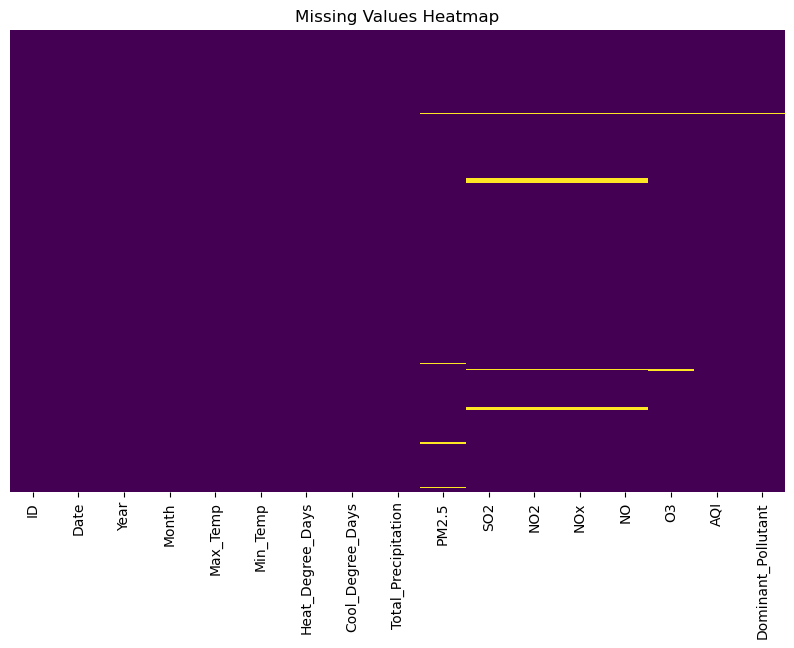

In [32]:
# Visualizing missing values with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Add title and show the plot
plt.title("Missing Values Heatmap")
plt.show()

Visualize scatterplots for each column to detect outliers and make informed decisions on imputation strategy starting with climate data and then particles data.

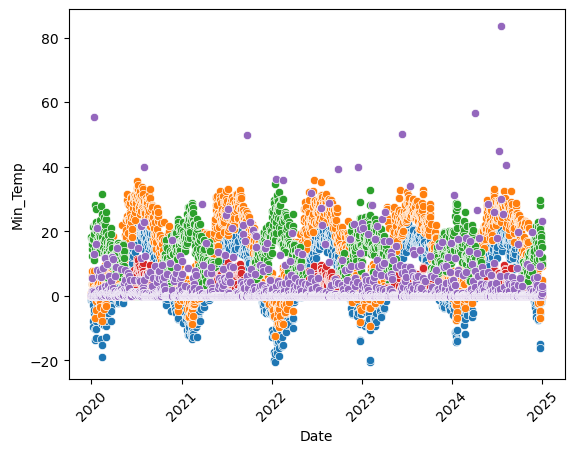

In [34]:
# Visualize Climate Data Outliers
sns.scatterplot(data=df, x='Date', y='Min_Temp')
sns.scatterplot(data=df, x='Date', y='Max_Temp')
sns.scatterplot(data=df, x='Date', y='Heat_Degree_Days')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='Cool_Degree_Days')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='Total_Precipitation')  # Significant Outliers
plt.xticks(rotation=45)
plt.show()

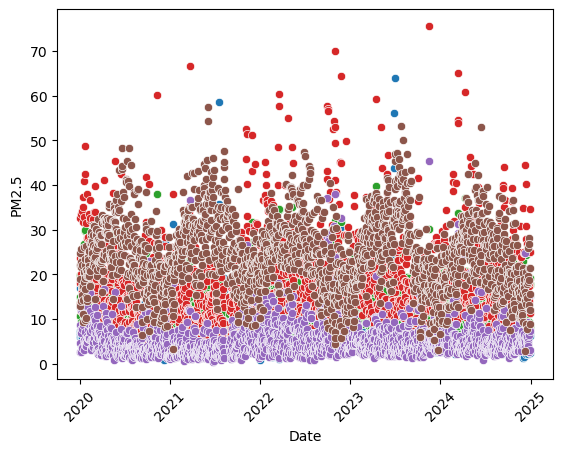

In [35]:
sns.scatterplot(data=df, x='Date', y='PM2.5')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='SO2')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='NO2')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='NOx')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='NO')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='O3')  # Significant Outliers + Seasonality Pattern
plt.xticks(rotation=45)
plt.show()

### 2.2 Imputing Missing values

To handle missing values, we will use mean imputation for fields where the scatterplot visualization did not show significant outliers, including Min_Temp and Max_Temp. For the remaining fields with significant outliers, we will apply median imputation. These fields include Heat_Degree_Days, Cool_Degree_Days, Total_Precipitation, PM2.5, SO2, NO2, NOx, NO, O3, and AQI.

In [38]:
# Mean imputation for Min_Temp and Max_Temp (no significant outliers)
df['Min_Temp'] = df['Min_Temp'].fillna(df['Min_Temp'].mean())
df['Max_Temp'] = df['Max_Temp'].fillna(df['Max_Temp'].mean())

# Median imputation for Heat_Degree_Days, Cool_Degree_Days, and Total_Precipitation (significant outliers)
df['Heat_Degree_Days'] = df['Heat_Degree_Days'].fillna(df['Heat_Degree_Days'].median())
df['Cool_Degree_Days'] = df['Cool_Degree_Days'].fillna(df['Cool_Degree_Days'].median()) 
df['Total_Precipitation'] = df['Total_Precipitation'].fillna(df['Total_Precipitation'].median())

In [39]:
# Median imputation for all particle data columns (significant outliers)
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].median())
df['SO2'] = df['SO2'].fillna(df['SO2'].median()) 
df['NO2'] = df['NO2'].fillna(df['NO2'].median())
df['NOx'] = df['NOx'].fillna(df['NOx'].median())
df['NO'] = df['NO'].fillna(df['NO'].median()) 
df['O3'] = df['O3'].fillna(df['O3'].median())
df['AQI'] = df['AQI'].fillna(df['AQI'].median())

## 3. Univariate Analysis

### 3.1 Numerical Univariate Analysis

We will analyze the distribution, outliers, and missing values in key variables to inform imputation and further analysis steps. 
Variables Analyzed:
<li>Min_Temp, Max_Temp, Heat_Degree_Days, Cool_Degree_Days, Total_Precipitation.</li>
<li>PM2.5, SO2, NO2, NOx, NO, O3, AQI.</li>

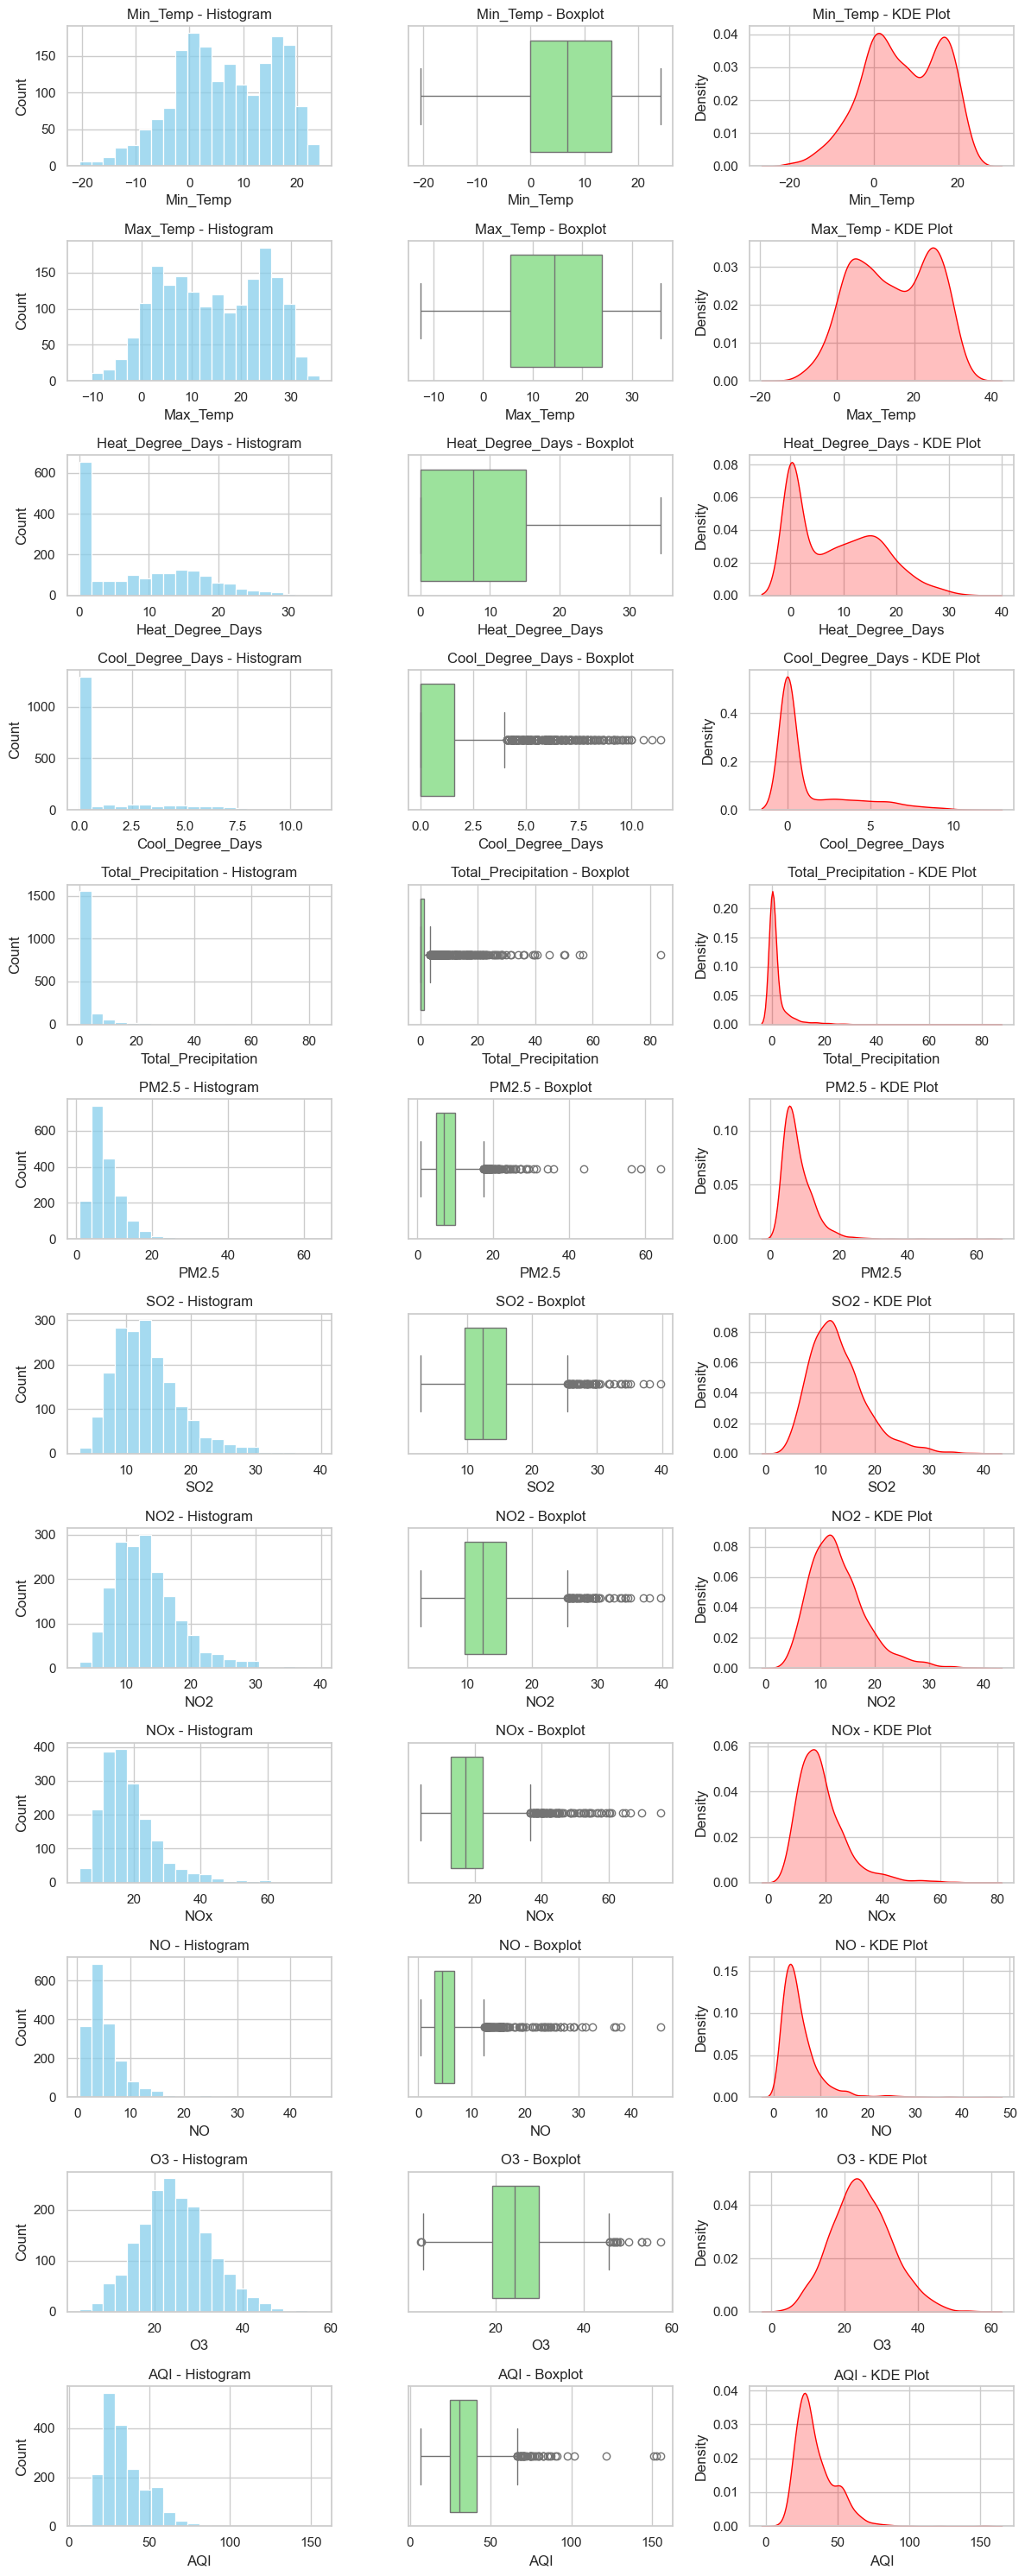

In [43]:
# Set style for the plots
sns.set(style="whitegrid")

# List of columns to analyze univariately
cols_to_analyze = ['Min_Temp', 'Max_Temp', 'Heat_Degree_Days', 'Cool_Degree_Days', 
                   'Total_Precipitation', 'PM2.5', 'SO2', 'NO2', 'NOx', 'NO', 'O3', 'AQI']

# Create a figure with subplots for each variable, adjust the size here
fig, axes = plt.subplots(len(cols_to_analyze), 3, figsize=(12, len(cols_to_analyze)*2.5))  # Adjusted size

# Iterate through each column for the univariate analysis
for i, col in enumerate(cols_to_analyze):
    # Histogram
    sns.histplot(df[col], kde=False, ax=axes[i, 0], bins=20, color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - Boxplot')
    
    # KDE plot (Kernel Density Estimate)
    sns.kdeplot(df[col], ax=axes[i, 2], color='red', fill=True)
    axes[i, 2].set_title(f'{col} - KDE Plot')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Based on the Numerical Univariate Analysis, we found that:

<li>Min_Temp: The distribution is slightly right-skewed, indicating that colder temperatures are more frequent, with a few extreme high temperatures.</li>
<li>Max_Temp: This variable is somewhat evenly distributed, suggesting a fairly balanced range of maximum temperatures over time.</li>
<li>The remaining variables, including Heat_Degree_Days, Cool_Degree_Days, and Total_Precipitation, exhibit extreme left skewness, suggesting frequent low values with a few extreme high values.</li>

### 3.2 Categorical Univariate Analysis

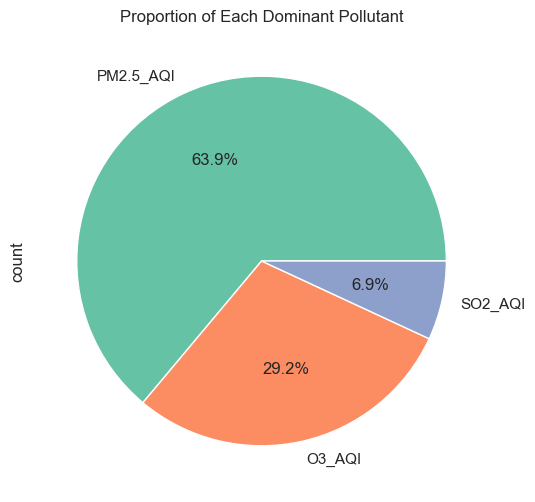

In [46]:
# Count occurrences of each dominant pollutant
pollutant_counts = df["Dominant_Pollutant"].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 6))
pollutant_counts.plot.pie(autopct="%1.1f%%", colors=sns.color_palette("Set2"))

# Add title
plt.title("Proportion of Each Dominant Pollutant")

# Show plot
plt.show()

Based on the Dominant_Pollutant field derived from AQI formulas, the air particle that most significantly contributes to deteriorating Toronto's air quality is PM2.5, which is the dominant pollutant 63.9% of the time. Following this, O3 contributes 29.2%, while SO2 accounts for 6.9%. NO2 contributes negligibly compared to the other pollutants, showing no presence in the dataset.

## 4. Bivariate Analysis

Bivariate analysis examines the relationships between two variables to identify patterns, dependencies, or potential predictors for AQI. The key objective is to determine which factors significantly influence AQI levels and assess multicollinearity among independent variables.

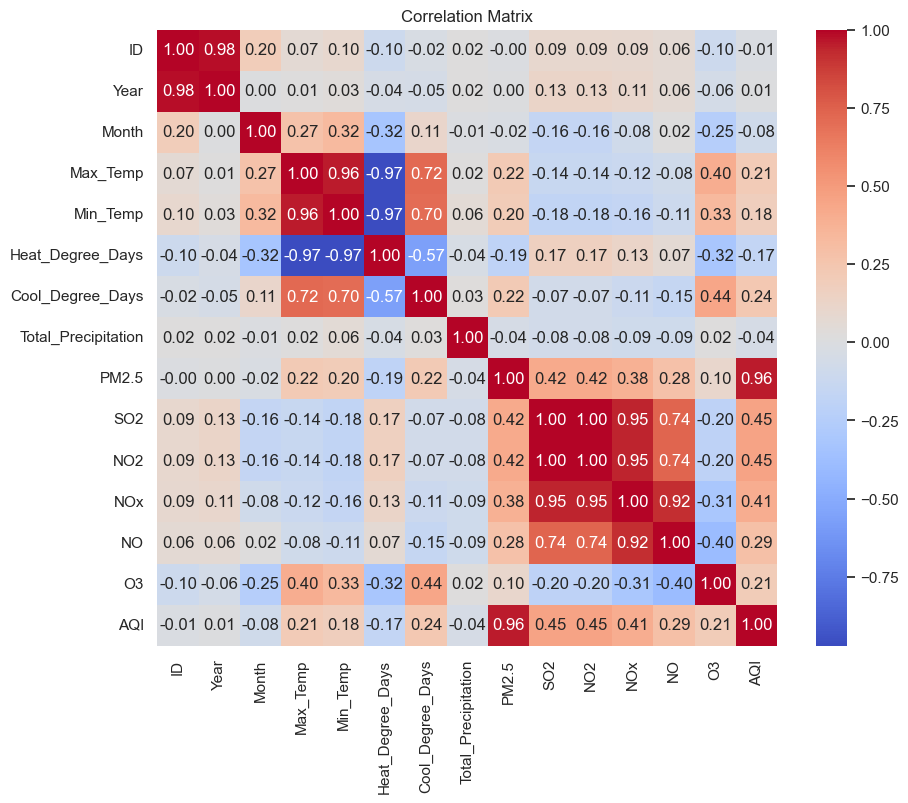

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

<h3>Key Findings:</h3>
<ul>
<li>PM2.5 has the strongest correlation with AQI, making it a key variable for further analysis.</li>
<li>O3 has a weak positive correlation with AQI but negatively correlates with other pollutants, highlighting its unique behavior.</li>
<li>SO2, NO2, NOx, and NO exhibit high correlations among themselves (0.74 - 1), indicating redundancy.</li>
<li>Temperature variables (Min_Temp and Max_Temp) behave similarly, both showing weak correlations with AQI but strong correlations with heating/cooling degree days.</li>
<li>Total Precipitation has negligible correlation with all variables, making it a weak candidate for predictive modeling.</li></ul>
</br></br>
</br></br>

To improve model efficiency and reduce redundancy:
<ul><li>Only one pollutant from each highly correlated group was retained:
<ul><li>NO2 was kept (part of AQI calculation) due to its stronger correlation over NO.
<li>NOx was retained (not part of AQI) to represent the other excluded pollutants.</ul></li>
<li>Mean_Temp was introduced instead of Min_Temp and Max_Temp, as it provides a balanced correlation with AQI while reducing redundancy.</li>
<li>Total Precipitation was dropped due to its negligible relationship with all other variables.</li></ul>

In [53]:
# Create Mean_Temp by averaging Min_Temp and Max_Temp
df['Mean_Temp'] = (df['Min_Temp'] + df['Max_Temp']) / 2

# Drop redundant variables based on correlation analysis
df = df.drop(columns=['SO2', 'NO', 'Min_Temp', 'Max_Temp', 'Total_Precipitation', 'Dominant_Pollutant'])

After removing redundant variables, a second correlation matrix was generated to confirm the refined relationships between the selected features and AQI. This ensures that the retained variables provide distinct and meaningful contributions to the analysis.

In [55]:
df.head()

,ID,Date,Year,Month,Heat_Degree_Days,Cool_Degree_Days,PM2.5,NO2,NOx,O3,AQI,Mean_Temp
0,1,2020-01-01,2020,1,18.1,0.0,6.71,10.69,13.29,24.83,27.958333,-0.10
1,2,2020-01-02,2020,1,14.4,0.0,7.33,13.65,18.16,22.00,30.541667,3.55
2,3,2020-01-03,2020,1,12.3,0.0,16.92,19.86,32.57,13.00,61.136481,5.65
3,4,2020-01-04,2020,1,16.0,0.0,6.04,14.99,23.60,18.88,25.166667,1.95
4,5,2020-01-05,2020,1,17.7,0.0,4.25,9.30,11.86,25.67,23.768519,0.35


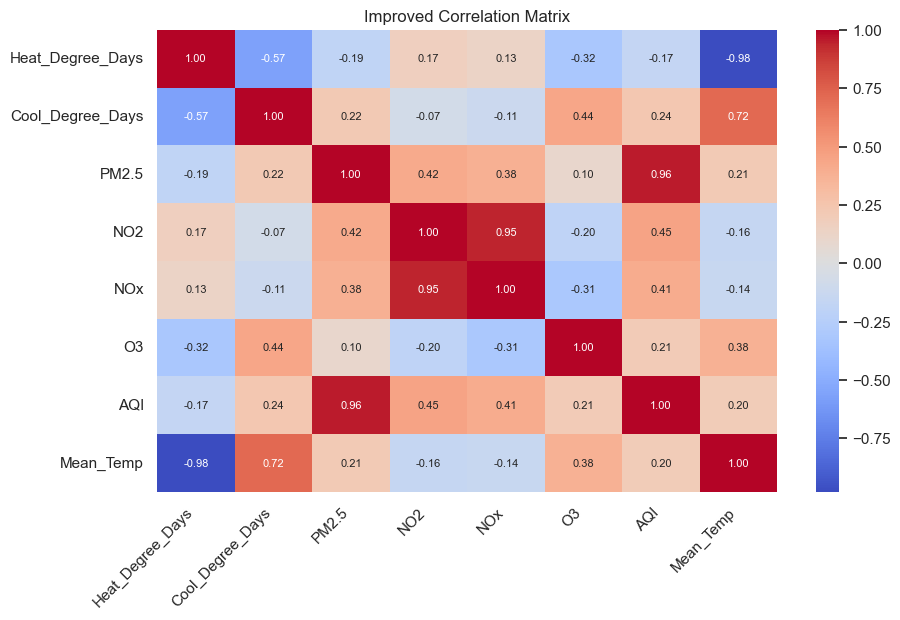

In [56]:
# Select only numeric columns (float64 and int64)
df_numeric = df.select_dtypes(include=['float64'])

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Visualize the updated correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})
plt.title('Improved Correlation Matrix')

# Rotate the x and y axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

# 4. Time Series Analysis:

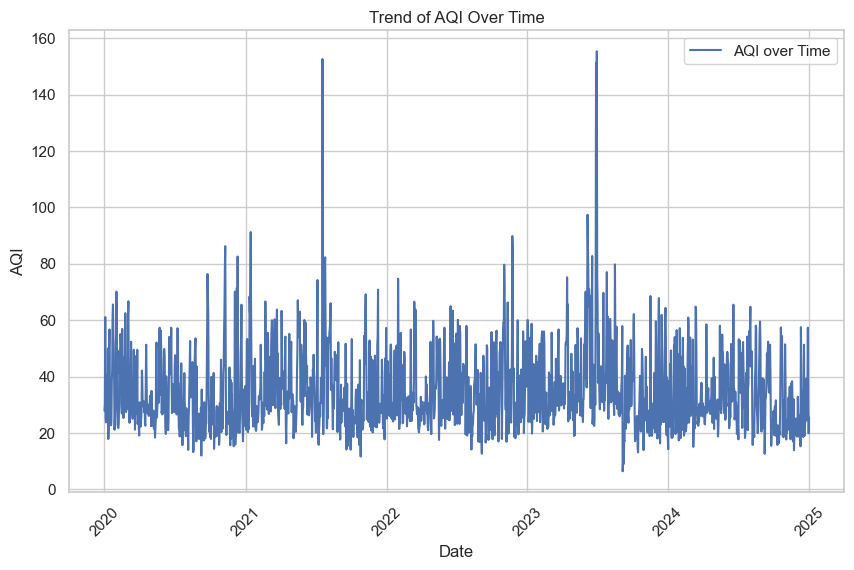

In [58]:
# 1. Trend Analysis: Plot AQI over time
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['AQI'], label="AQI over Time")
plt.title('Trend of AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.legend()
plt.show()

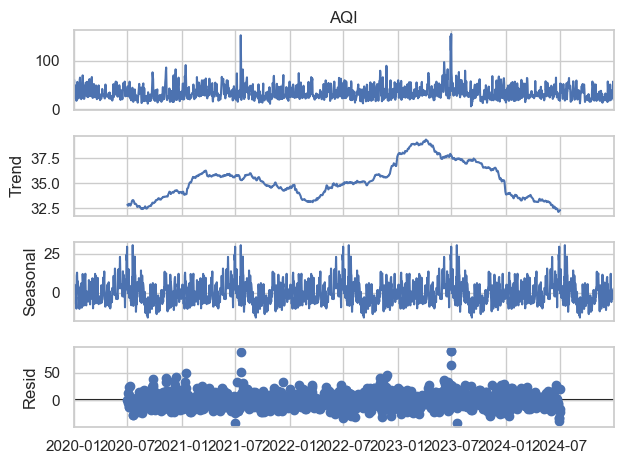

In [59]:
# 2. Seasonality Analysis: Decompose time series data
# Set the 'Date' column as the index for time series analysis
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['AQI'], model='additive', period=365)  # Assuming daily data with yearly seasonality
decomposition.plot()
plt.show()

In [60]:
# 3. Stationarity Check: Augmented Dickey-Fuller Test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The series is stationary")
    else:
        print("The series is non-stationary")

# Test stationarity for AQI
adf_test(df['AQI'])

ADF Statistic: -6.207112418263731
p-value: 5.622757261462448e-08
The series is stationary


In [61]:
# We need to make sure there are no null values in AQI
df['AQI'].isnull().sum()

0

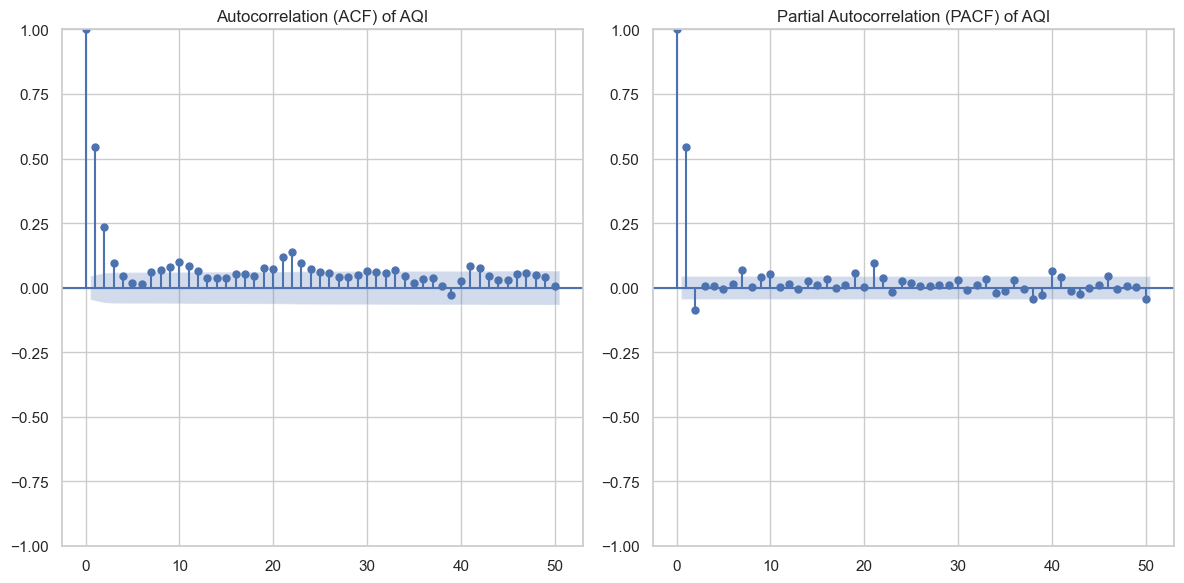

In [62]:
# 4. Autocorrelation and Partial Autocorrelation
# Set up the figure and axes for the two plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ACF (Autocorrelation Function)
plot_acf(df['AQI'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) of AQI')

# PACF (Partial Autocorrelation Function)
plot_pacf(df['AQI'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF) of AQI')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

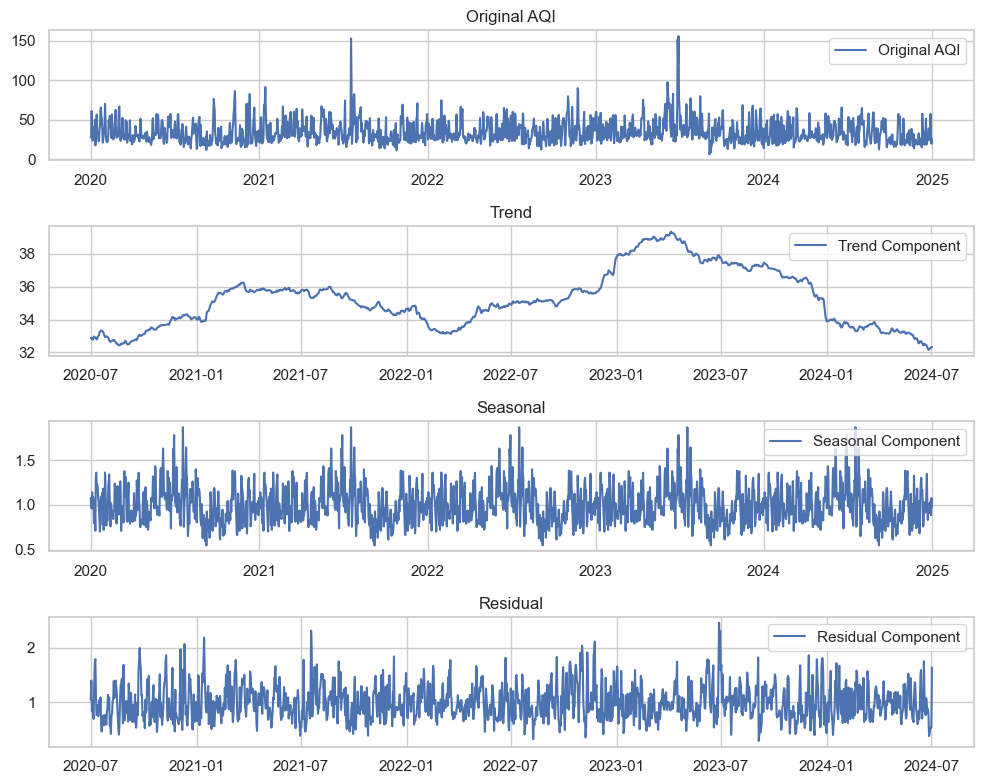

In [63]:
# 5. Decompose Time Series into Trend, Seasonal, and Residual
decomposition = seasonal_decompose(df['AQI'], model='multiplicative', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot decomposed components
plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(df['AQI'], label='Original AQI')
plt.legend(loc='best')
plt.title('Original AQI')

plt.subplot(412)
plt.plot(trend, label='Trend Component')
plt.legend(loc='best')
plt.title('Trend')

plt.subplot(413)
plt.plot(seasonal, label='Seasonal Component')
plt.legend(loc='best')
plt.title('Seasonal')

plt.subplot(414)
plt.plot(residual, label='Residual Component')
plt.legend(loc='best')
plt.title('Residual')

plt.tight_layout()
plt.show()

# 4. Feature Selection and Engineering

In [65]:
# Create the 'Season' field based on the 'Month' column
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Use .loc to avoid SettingWithCopyWarning
df.loc[:, 'Season'] = df['Month'].apply(assign_season)

# Reorganize columns structure 
columns_order = ['AQI', 'PM2.5', 'O3', 'NO2', 'NOx', 'Mean_Temp', 'Season', 'Month', 'Heat_Degree_Days', 'Cool_Degree_Days']
df = df[columns_order]

# Display the first few rows to confirm changes
df.head()

,AQI,PM2.5,O3,NO2,NOx,Mean_Temp,Season,Month,Heat_Degree_Days,Cool_Degree_Days
Date,,,,,,,,,,
2020-01-01,27.958333,6.71,24.83,10.69,13.29,-0.10,Winter,1,18.1,0.0
2020-01-02,30.541667,7.33,22.00,13.65,18.16,3.55,Winter,1,14.4,0.0
2020-01-03,61.136481,16.92,13.00,19.86,32.57,5.65,Winter,1,12.3,0.0
2020-01-04,25.166667,6.04,18.88,14.99,23.60,1.95,Winter,1,16.0,0.0
2020-01-05,23.768519,4.25,25.67,9.30,11.86,0.35,Winter,1,17.7,0.0


# 5. Model Selection & Evaluation

## 5.1 Baseline Models

In [68]:
# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to the 'Season' column
df['Season'] = label_encoder.fit_transform(df['Season'])

# Check the first few rows to confirm the changes
df.head()

,AQI,PM2.5,O3,NO2,NOx,Mean_Temp,Season,Month,Heat_Degree_Days,Cool_Degree_Days
Date,,,,,,,,,,
2020-01-01,27.958333,6.71,24.83,10.69,13.29,-0.10,3,1,18.1,0.0
2020-01-02,30.541667,7.33,22.00,13.65,18.16,3.55,3,1,14.4,0.0
2020-01-03,61.136481,16.92,13.00,19.86,32.57,5.65,3,1,12.3,0.0
2020-01-04,25.166667,6.04,18.88,14.99,23.60,1.95,3,1,16.0,0.0
2020-01-05,23.768519,4.25,25.67,9.30,11.86,0.35,3,1,17.7,0.0


In [69]:
# Split the data into features (X) and target (y)
X = df.drop(columns=['AQI'])  # Features (excluding AQI, which is the target)
y = df['AQI']  # Target variable (AQI)

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1461, 9)
Testing set size: (366, 9)


In [70]:
# One-Hot Encoding for the 'Season' column
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

# Now, the 'Season' column will be represented as three binary columns: 'Season_Spring', 'Season_Summer', 'Season_Fall'.

In [71]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression - MSE:", mse)
print("Linear Regression - R^2:", r2)

Linear Regression - MSE: 10.762815844739409
Linear Regression - R^2: 0.9430528973797508


In [72]:
# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest - MSE:", mse_rf)
print("Random Forest - R^2:", r2_rf)

Random Forest - MSE: 1.112542728756748
Random Forest - R^2: 0.9941134285062687


In [73]:
# Initialize the XGBoost model
xgb_model = XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model performance
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost - MSE:", mse_xgb)
print("XGBoost - R^2:", r2_xgb)

XGBoost - MSE: 5.662343504444946
XGBoost - R^2: 0.9700399912745571


<h2>Conclusion:</h2>
Based on the evaluation of each model, Random Forest emerged as the highest-performing model, achieving an R² of 0.9941 and an MSE of 1.11. This means that the model explains 99.41% of the variance in the target variable, with a relatively small margin of error. This performance highlights the model's strong ability to fit the data and make accurate predictions.

## 5.2 Time Series Models

<h2>ARIMA:</h2>

In [109]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test
result = adfuller(df['AQI'])  # Replace 'AQI' with your actual column name

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("The data is stationary.")
else:
    print("The data is not stationary, differencing is needed.")

ADF Statistic: -6.207112418263731
p-value: 5.622757261462448e-08
The data is stationary.


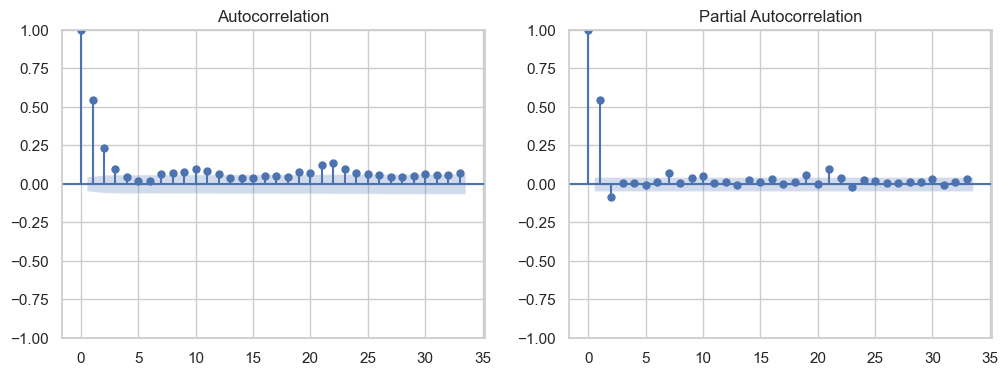

In [111]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df['AQI'].dropna(), ax=axes[0])   # ACF for MA(q)
plot_pacf(df['AQI'].dropna(), ax=axes[1])  # PACF for AR(p)

plt.show()

In [113]:
from statsmodels.tsa.arima.model import ARIMA

# Set ARIMA order (p, d, q) based on ACF/PACF plots
p, d, q = 1, 1, 0  

# Fit the model
model = ARIMA(df['AQI'], order=(p, d, q))
model_fit = model.fit()

# Summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1827
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -7340.248
Date:                Wed, 26 Mar 2025   AIC                          14684.496
Time:                        21:46:05   BIC                          14695.516
Sample:                             0   HQIC                         14688.561
                               - 1827                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1593      0.017     -9.448      0.000      -0.192      -0.126
sigma2       181.6958      3.346     54.307      0.000     175.138     188.253
Ljung-Box (L1) (Q):                   2.23   Jarque-

C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


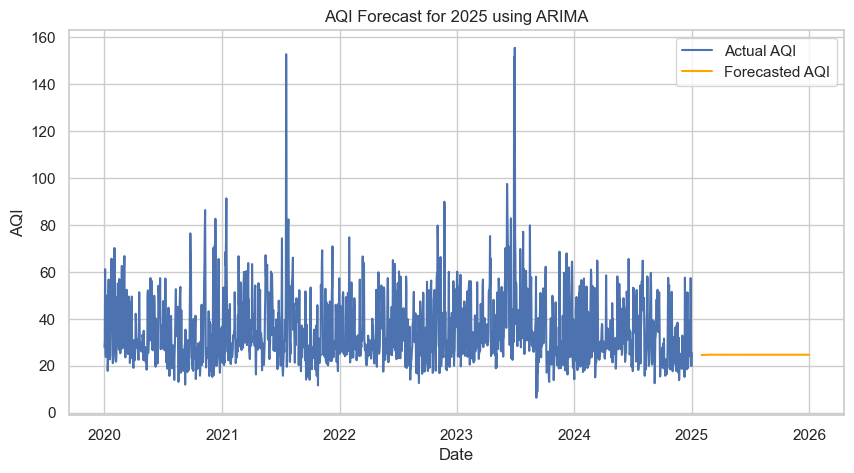

In [115]:
# Forecast future values (adjust the steps for how many months you want to predict)
n_steps = 12  # Predict for 12 months
forecast = model_fit.forecast(steps=n_steps)

# Generate future dates
future_dates = pd.date_range(df.index[-1], periods=n_steps + 1, freq='ME')[1:]

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['AQI'], label='Actual AQI')  # Historical AQI
plt.plot(future_dates, forecast, label='Forecasted AQI', color='orange')
plt.legend()
plt.title('AQI Forecast for 2025 using ARIMA')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

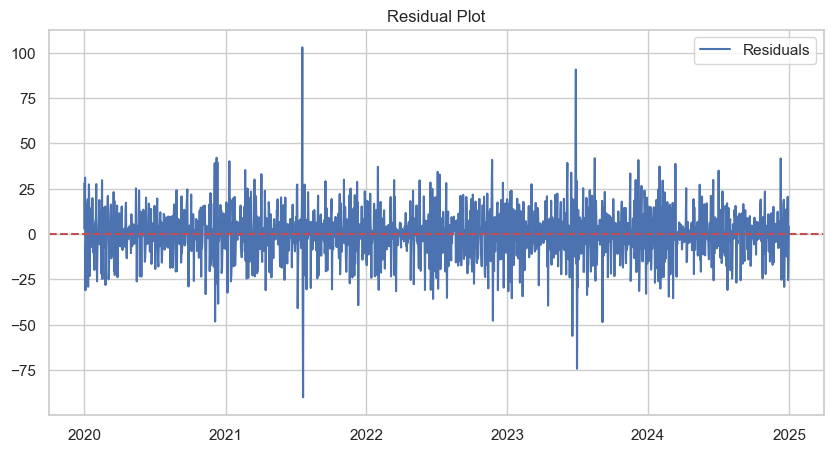

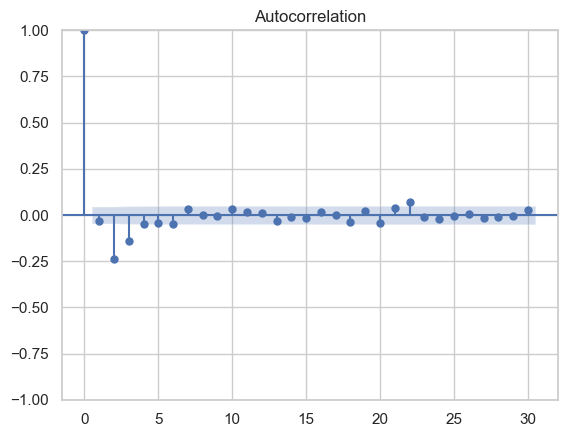

In [135]:
import statsmodels.api as sm  
residuals = model_fit.resid  

# Plot Residuals
plt.figure(figsize=(10,5))
plt.plot(residuals, label="Residuals")
plt.axhline(0, linestyle='--', color='r')
plt.legend()
plt.title("Residual Plot")
plt.show()

# ACF Plot of Residuals
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.show()

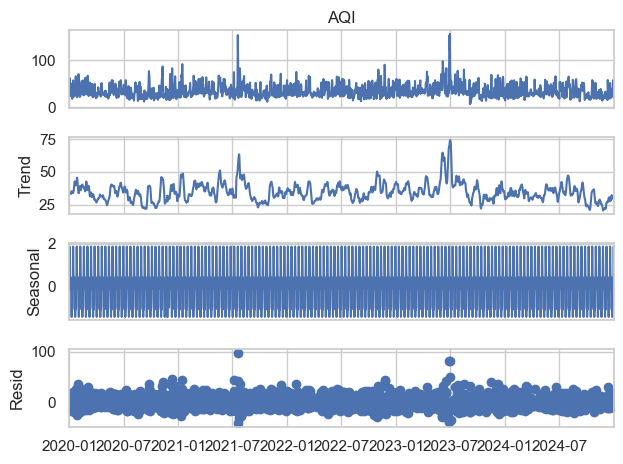

In [137]:
import statsmodels.api as sm  

# Seasonal Decomposition of Time Series
decomposition = sm.tsa.seasonal_decompose(df['AQI'], model='additive', period=12)  

# Plot decomposition
decomposition.plot()
plt.show()

C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                 1827
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -7052.475
Date:                            Wed, 26 Mar 2025   AIC                          14114.949
Time:                                    22:45:58   BIC                          14142.427
Sample:                                         0   HQIC                         14125.092
                                           - 1827                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5256      0.016     32.246      0.000       0.494       0.558
ma.L1         -0.9861      0.005   

C:\Users\ahmed\AppData\Local\Temp\ipykernel_52688\694105728.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(df.index[-1], periods=13, freq='M')[1:]
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


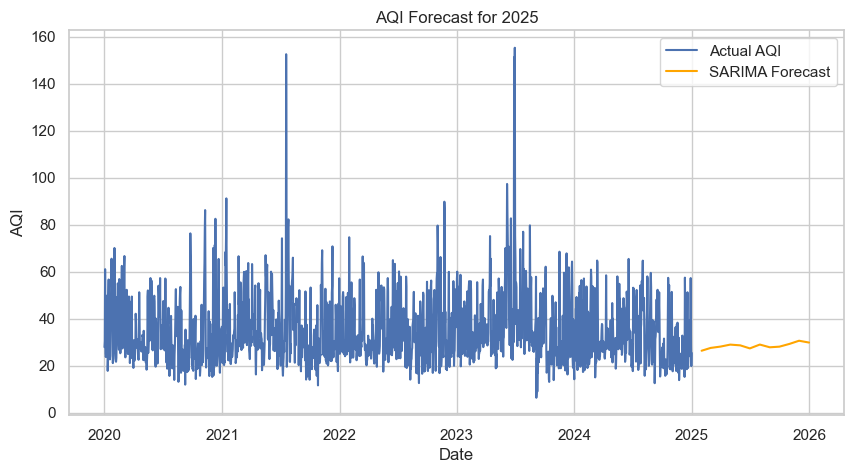

In [143]:
from statsmodels.tsa.statespace.sarimax import SARIMAX  

# Fit SARIMA model
sarima_model = SARIMAX(df['AQI'], order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False)  
sarima_fit = sarima_model.fit()

# Print summary
print(sarima_fit.summary())

# Forecast for 2025
future_dates = pd.date_range(df.index[-1], periods=13, freq='M')[1:]
future_forecast = sarima_fit.forecast(steps=12)

# Plot Forecast
plt.figure(figsize=(10,5))
plt.plot(df.index, df['AQI'], label="Actual AQI")
plt.plot(future_dates, future_forecast, label="SARIMA Forecast", color="orange")
plt.legend()
plt.title("AQI Forecast for 2025")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2020-01-01 to 2024-12-31
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AQI               1827 non-null   float64
 1   PM2.5             1827 non-null   float64
 2   O3                1827 non-null   float64
 3   NO2               1827 non-null   float64
 4   NOx               1827 non-null   float64
 5   Mean_Temp         1827 non-null   float64
 6   Month             1827 non-null   int64  
 7   Heat_Degree_Days  1827 non-null   float64
 8   Cool_Degree_Days  1827 non-null   float64
 9   Season_1          1827 non-null   bool   
 10  Season_2          1827 non-null   bool   
 11  Season_3          1827 non-null   bool   
dtypes: bool(3), float64(8), int64(1)
memory usage: 148.1 KB


## 2. Random Forest

### 2.1 Fine-Tuning

In [77]:
# Define the model
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameters to tune
param_grid_rf = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Max depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None],  # Max features to consider for splits (no 'auto')
    'bootstrap': [True, False]  # Whether to use bootstrap samples
}

# Apply RandomizedSearchCV instead of GridSearchCV
random_search_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid_rf, 
                                      n_iter=50, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the model
random_search_rf.fit(X_train, y_train)

# Get the best parameters
best_rf_params = random_search_rf.best_params_
print(f"Best Random Forest Hyperparameters: {best_rf_params}")

# Evaluate the model with the best parameters
best_rf_model = random_search_rf.best_estimator_
rf_predictions = best_rf_model.predict(X_test)

# Evaluate performance
mse_rf = mean_squared_error(y_test, rf_predictions)
r2_rf = r2_score(y_test, rf_predictions)

print(f"Fine-Tuned Random Forest - MSE: {mse_rf}")
print(f"Fine-Tuned Random Forest - R^2: {r2_rf}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Random Forest Hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'bootstrap': False}
Fine-Tuned Random Forest - MSE: 0.8349491226609017
Fine-Tuned Random Forest - R^2: 0.9955822032025107


### 2.2 Cross-Validation

In [79]:
# Perform cross-validation with the fine-tuned model
cross_val_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Print the cross-validation results
print(f"Cross-validation MSE scores: {cross_val_scores}")
print(f"Average Cross-validation MSE: {cross_val_scores.mean()}")

Cross-validation MSE scores: [-0.73927783 -0.75307876 -1.61542394 -3.88272801 -3.20134004]
Average Cross-validation MSE: -2.038369715936221


### 2.3 Model Evaluation

In [81]:
# Evaluate the model on the test set
test_predictions = best_rf_model.predict(X_test)

# Evaluate performance on test set
mse_test = mean_squared_error(y_test, test_predictions)
r2_test = r2_score(y_test, test_predictions)

print(f"Test Set - MSE: {mse_test}")
print(f"Test Set - R^2: {r2_test}")

Test Set - MSE: 0.8349491226609017
Test Set - R^2: 0.9955822032025107


### 2.4 Model Validation

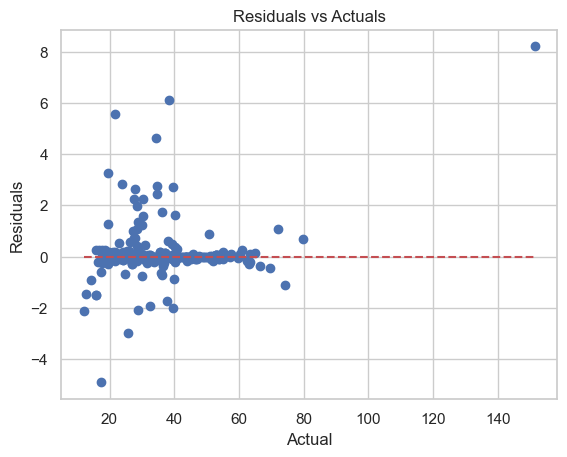

In [83]:
# Plot the residuals
residuals = y_test - test_predictions
plt.scatter(y_test, residuals)
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.max(), colors='r', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.title('Residuals vs Actuals')
plt.show()

In [84]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display top 10 important features
print(feature_importance.head(10))

            Feature    Importance
0             PM2.5  9.525984e-01
1                O3  3.730531e-02
2               NO2  8.193420e-03
3               NOx  6.839807e-04
4         Mean_Temp  5.783293e-04
8  Cool_Degree_Days  3.456833e-04
7  Heat_Degree_Days  2.154736e-04
6             Month  7.850307e-05
5            Season  9.364977e-07


<h2>Conclusion:</h2>
<ul><li><strong>Performance Evaluation:</strong></br>
The model exhibits outstanding performance, with an R² score of 0.9956 and MSE of 0.83 on the test set. These metrics suggest that the model has strong predictive power.</li>

<li><strong>Feature Importance Insights:</strong></br>
The model relies heavily on PM2.5 as the most important feature, which makes sense in environmental pollution prediction tasks, as PM2.5 is a critical air quality indicator.</li></ul>

# 5. Forecating

In [87]:
# Let's assume the target variable is in 'target_column' and features are other columns
train_size = int(len(df) * 0.8)  # Use 80% of data for training, 20% for testing
train_data = df[:train_size]
test_data = df[train_size:]

X_train = train_data.drop(columns=['AQI'])  # Drop the target column
y_train = train_data['AQI']

X_test = test_data.drop(columns=['AQI'])
y_test = test_data['AQI']

In [88]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, bootstrap=False)
rf_model.fit(X_train, y_train)

RandomForestRegressor(bootstrap=False, max_depth=20)

In [89]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, bootstrap=False)
rf_model.fit(X_train, y_train)

RandomForestRegressor(bootstrap=False, max_depth=20)

In [90]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse}")
print(f"Test R²: {r2}")

Test MSE: 1.0176283097549734
Test R²: 0.9927808450705972


In [91]:
# Get the last available row (latest data)
latest_data = df.iloc[-1].drop('AQI')  # Drop the target column, as it's the value you're predicting

# Reshape the latest data to match the model's input shape
latest_data = latest_data.values.reshape(1, -1)

# Predict the next value
future_prediction = rf_model.predict(latest_data)
print(f"Next predicted value: {future_prediction[0]}")

Next predicted value: 25.500000000000004


C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [92]:
# Initialize an empty list to store predictions
future_predictions = []

# Number of future steps to forecast
n_steps = 5

# Forecast the next n_steps
current_input = latest_data
for _ in range(n_steps):
    next_pred = rf_model.predict(current_input)
    future_predictions.append(next_pred[0])
    
    # Prepare the input for the next step by shifting the previous predictions
    current_input = current_input.copy()  # Copy the current input
    current_input[0, -1] = next_pred  # Update the last value with the predicted value

print(f"Future predictions: {future_predictions}")

Future predictions: [25.500000000000004, 25.500000000000004, 25.500000000000004, 25.500000000000004, 25.500000000000004]


C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


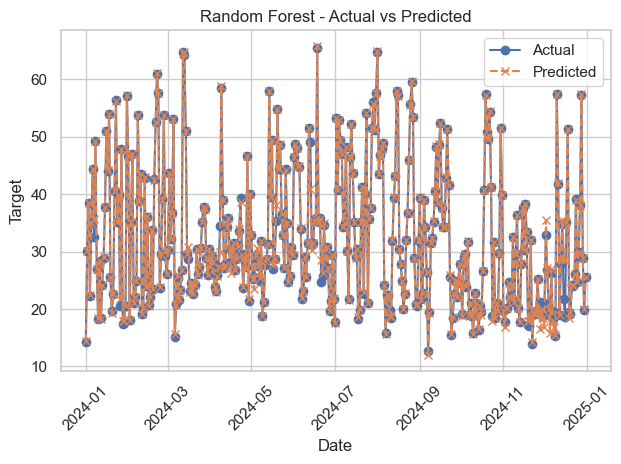

In [93]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values with different line styles and markers
plt.plot(df.index[train_size:], y_test, label='Actual', linestyle='-', marker='o')  # Actual values with markers
plt.plot(df.index[train_size:], y_pred, label='Predicted', linestyle='--', marker='x')  # Predicted values with different markers
plt.legend()
plt.title('Random Forest - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Target')
plt.xticks(rotation=45)  # Rotate x-axis labels if necessary
plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_52688\2406324279.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(df.index[-1], periods=n_steps + 1, freq='M')[1:]  # Future dates


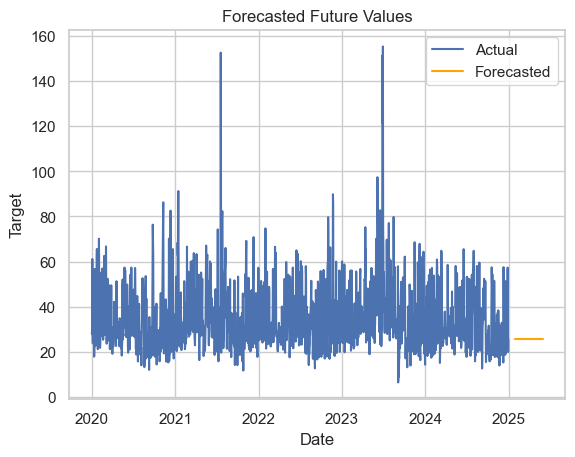

In [94]:
# Plot future predictions
plt.plot(df.index, df['AQI'], label='Actual')  # All actual data
future_dates = pd.date_range(df.index[-1], periods=n_steps + 1, freq='M')[1:]  # Future dates
plt.plot(future_dates, future_predictions, label='Forecasted', color='orange')
plt.legend()
plt.title('Forecasted Future Values')
plt.xlabel('Date')
plt.ylabel('Target')
plt.show()

In [95]:
print("Actual values:", y_test[:5])  # First 5 actual values
print("Predicted values:", y_pred[:5])  # First 5 predicted values


Actual values: Date
2024-01-01    14.285714
2024-01-02    30.041667
2024-01-03    38.541667
2024-01-04    22.296296
2024-01-05    34.916667
Name: AQI, dtype: float64
Predicted values: [14.35333333 30.04166667 38.54166667 22.37361111 34.91666667]


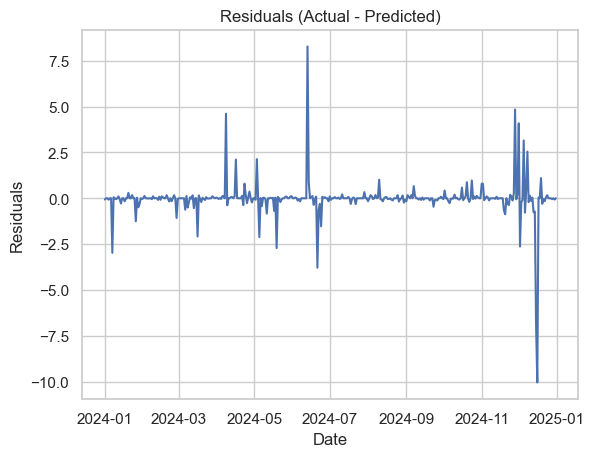

In [96]:
residuals = y_test - y_pred
plt.plot(df.index[train_size:], residuals)
plt.title('Residuals (Actual - Predicted)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.show()

In [97]:
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')  # Daily dates for 2025

In [98]:
# Prepare the features for 2025
future_features = prepare_features_for_forecasting(future_dates)  # Function to generate future features
future_predictions = model.predict(future_features)

NameError: name 'prepare_features_for_forecasting' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Historical data plot (assumes 'df' is your original dataset)
plt.plot(df.index, df['AQI'], label='Actual AQI')  # Historical AQI values

# Forecasted data plot for 2025
plt.plot(future_dates, future_predictions, label='Forecasted AQI for 2025', color='orange')

# Customize the plot
plt.legend()
plt.title('AQI Forecast for 2025')
plt.xlabel('Date')
plt.ylabel('Air Quality Index (AQI)')
plt.xticks(rotation=45)
plt.tight_layout()  # Prevent label overlap
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Assuming you have a function that generates the necessary features for forecasting
def prepare_features_for_forecasting(dates):
    # Extract time-based features (example: Month, DayOfWeek)
    features = pd.DataFrame()
    features['Month'] = dates.month
    features['DayOfWeek'] = dates.weekday
    features['DayOfYear'] = dates.dayofyear

    # Assuming you also have weather data like temperature, PM2.5, etc.
    # You might need to import or estimate these values for 2025 (for simplicity, I'll set them to NaN)
    features['PM2.5'] = np.nan  # Replace with actual data or estimates for 2025
    features['Temperature'] = np.nan  # Replace with actual data or estimates for 2025
    features['O3'] = np.nan  # Replace with actual data or estimates for 2025

    # Add any other features you used in the model (e.g., seasonal features, holidays, etc.)

    return features

# Create future dates for 2025
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')

# Prepare features for the future dates
future_features = prepare_features_for_forecasting(future_dates)

# Use your trained model to make predictions for 2025
future_predictions = rf_model.predict(future_features)

# Plotting
plt.plot(df.index, df['AQI'], label='Actual AQI')  # Historical AQI values
plt.plot(future_dates, future_predictions, label='Forecasted AQI for 2025', color='orange')  # Forecasted AQI
plt.legend()
plt.title('AQI Forecast for 2025')
plt.xlabel('Date')
plt.ylabel('Air Quality Index (AQI)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(rf_model.feature_names_in_)
# Select only the features that were used during training
expected_features = ['PM2.5', 'O3', 'NO2', 'NOx', 'Mean_Temp', 'Month', 'Heat_Degree_Days',
 'Cool_Degree_Days', 'Season_1', 'Season_2', 'Season_3']

future_features = future_features[expected_features]
